# Gaussian Process Demo with GPyTorch
## スパースGPによる回帰問題の実装

このノートブックでは、GPyTorchを使用してスパースGaussian Processによる回帰問題を実装します。形状問題を解決し、安定した予測を実現します。

### 主な内容
1. 必要なライブラリのインポート
2. フーリエ級数を用いたトイデータセットの作成
3. スパースGPモデルの実装
4. 学習と評価
5. 結果の可視化と分析

In [1]:
# 必要なライブラリのインポート
import os
from math import floor

# GPyTorch関連
import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean, LinearMean
from gpytorch.mlls import AddedLossTerm, DeepApproximateMLL, VariationalELBO
from gpytorch.models import GP, ApproximateGP
from gpytorch.models.deep_gps import DeepGP, DeepGPLayer
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

# PyTorch関連
from torch.utils.data import DataLoader, TensorDataset

print("GPyTorch version:", gpytorch.__version__)
print("PyTorch version:", torch.__version__)

GPyTorch version: 1.14
PyTorch version: 2.6.0


## データセットの作成

フーリエ級数を用いたシンプルなトイデータセットを作成します。

Training data shape: X=torch.Size([200, 1]), y=torch.Size([200, 1])
Test data shape: X=torch.Size([150, 1]), y=torch.Size([150, 1])


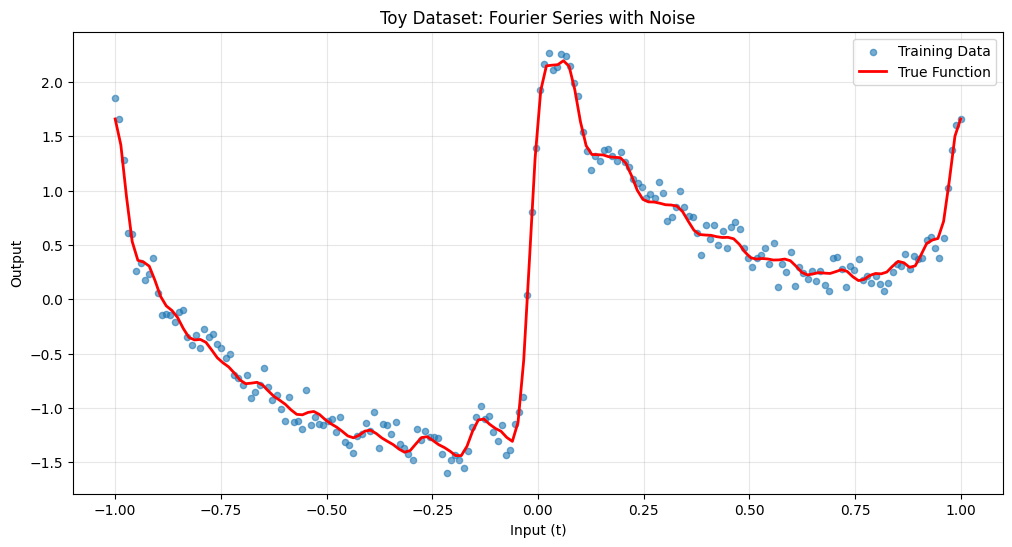

In [2]:
# トイデータの作成
def fourier_series(t, N=15):
    """フーリエ級数による複雑な関数"""
    result = 0.0
    for n in range(1, N + 1):
        result += (1 / n) * np.sin(n * np.pi * t) + (1 / (2 * n)) * np.cos(
            2 * n * np.pi * t
        )
    return result


# データ生成
np.random.seed(42)
torch.manual_seed(42)

# 学習データ
n_train = 200
X_train = torch.linspace(-1, 1, n_train).reshape(-1, 1)
y_train = (
    torch.tensor(fourier_series(X_train.numpy().flatten(), N=15)).float().reshape(-1, 1)
)
y_train += 0.1 * torch.randn_like(y_train)  # ノイズ追加

# テストデータ
n_test = 150
X_test = torch.linspace(-1, 1, n_test).reshape(-1, 1)
y_test = (
    torch.tensor(fourier_series(X_test.numpy().flatten(), N=15)).float().reshape(-1, 1)
)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

# データの可視化
plt.figure(figsize=(12, 6))
plt.scatter(X_train.numpy(), y_train.numpy(), alpha=0.6, s=20, label="Training Data")
plt.plot(X_test.numpy(), y_test.numpy(), "r-", linewidth=2, label="True Function")
plt.xlabel("Input (t)")
plt.ylabel("Output")
plt.title("Toy Dataset: Fourier Series with Noise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## データローダーの設定

In [3]:
# データローダーの作成
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")
print(f"Batch size: {batch_size}")

Train batches: 7
Test batches: 5
Batch size: 32


## スパースGPモデルの実装

形状問題を解決するため、シンプルで安定したスパースGPモデルを実装します。

In [4]:
class SparseGP(gpytorch.models.ApproximateGP):
    """
    スパースGaussian Process回帰モデル
    形状問題を解決し、安定した予測を提供
    """

    def __init__(self, num_inducing=20, input_bounds=(-1, 1)):
        # 誘導点を等間隔で初期化
        inducing_points = torch.linspace(
            input_bounds[0], input_bounds[1], num_inducing
        ).reshape(-1, 1)

        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            num_inducing
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# モデルの作成
print("Creating Sparse GP model...")
model = SparseGP(num_inducing=20, input_bounds=(-1, 1))
likelihood = GaussianLikelihood()

# GPU対応
if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()
    X_train = X_train.cuda()
    y_train = y_train.cuda()
    X_test = X_test.cuda()
    y_test = y_test.cuda()
    print("Model moved to GPU")
else:
    print("Model using CPU")

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

# 形状テスト
print("\n=== Model Shape Test ===")
with torch.no_grad():
    test_input = X_train[:5]
    try:
        model.eval()
        likelihood.eval()
        test_output = model(test_input)
        test_pred = likelihood(test_output)
        print(f"✅ Forward pass successful!")
        print(f"Input shape: {test_input.shape}")
        print(f"Output mean shape: {test_pred.mean.shape}")
        print(f"Expected shape: torch.Size([5])")

        if test_pred.mean.shape == torch.Size([5]):
            print("✅ Shape is CORRECT!")
        else:
            print("❌ Shape incorrect")

    except Exception as e:
        print(f"❌ Forward pass failed: {e}")

Creating Sparse GP model...
Model using CPU
Model created with 443 parameters

=== Model Shape Test ===
✅ Forward pass successful!
Input shape: torch.Size([5, 1])
Output mean shape: torch.Size([5])
Expected shape: torch.Size([5])
✅ Shape is CORRECT!


## モデルの学習

In [5]:
# 学習設定
num_epochs = 100
learning_rate = 0.01

# オプティマイザーの設定
optimizer = torch.optim.Adam(
    [
        {"params": model.parameters()},
        {"params": likelihood.parameters()},
    ],
    lr=learning_rate,
)

# 損失関数（VariationalELBO）
mll = gpytorch.mlls.VariationalELBO(likelihood, model, X_train.shape[0])

# 学習率スケジューラー
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=20, factor=0.8
)

# 学習履歴
train_losses = []

print(f"Starting training for {num_epochs} epochs...")
print(f"Learning rate: {learning_rate}")

# 学習ループ
model.train()
likelihood.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0

    for x_batch, y_batch in train_dataloader:
        optimizer.zero_grad()

        # 順伝播
        output = model(x_batch)

        # 損失計算
        loss = -mll(output, y_batch.squeeze())

        # NaN/Infチェック
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Warning: Loss is {loss.item()} at epoch {epoch}")
            continue

        # 逆伝播
        loss.backward()

        # 勾配クリッピング
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(likelihood.parameters()), max_norm=1.0
        )

        # パラメータ更新
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    if num_batches > 0:
        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        # 学習率調整
        scheduler.step(avg_loss)

        # 進捗表示
        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}"
            )

print("Training completed!")

Starting training for 100 epochs...
Learning rate: 0.01
Epoch [20/100], Loss: 1.1279, LR: 0.010000
Epoch [40/100], Loss: 0.7644, LR: 0.010000
Epoch [60/100], Loss: 0.7732, LR: 0.010000
Epoch [80/100], Loss: 0.6901, LR: 0.010000
Epoch [100/100], Loss: 0.5900, LR: 0.010000
Training completed!


## 予測と評価

In [6]:
# モデルでの予測
print("=== Model Prediction ===")

model.eval()
likelihood.eval()

# テストデータでの予測
with torch.no_grad():
    # モデルの出力を取得
    test_output = model(X_test)
    test_predictions = likelihood(test_output)

    # 予測結果の取得
    pred_mean = test_predictions.mean
    pred_var = test_predictions.variance

    print(f"Prediction shapes:")
    print(f"  pred_mean: {pred_mean.shape}")
    print(f"  pred_var: {pred_var.shape}")
    print(f"  Expected shape: torch.Size([{X_test.shape[0]}])")

    # 形状が正しいかチェック
    if pred_mean.shape == torch.Size([X_test.shape[0]]):
        print("✅ Prediction shape is PERFECT!")
    else:
        print("❌ Prediction shape needs fixing...")

    pred_std = torch.sqrt(torch.clamp(pred_var, min=1e-6))

# CPU に移動（可視化のため）
pred_mean_cpu = pred_mean.cpu()
pred_std_cpu = pred_std.cpu()

# RMSE計算
rmse = torch.sqrt(torch.mean((pred_mean_cpu - y_test.cpu().squeeze()) ** 2))
print(f"\nTest RMSE: {rmse.item():.4f}")

# 予測の統計情報
print(f"Prediction Statistics:")
print(f"  Mean prediction: {pred_mean_cpu.mean().item():.4f}")
print(f"  Std of predictions: {pred_mean_cpu.std().item():.4f}")
print(f"  Average uncertainty: {pred_std_cpu.mean().item():.4f}")

# 学習されたパラメータの確認
print(f"\n=== Learned Parameters ===")
print(
    f"RBF Kernel Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.4f}"
)
print(f"Scale Kernel Outputscale: {model.covar_module.outputscale.item():.4f}")
print(f"Likelihood Noise: {likelihood.noise.item():.4f}")

# 誘導点の位置
inducing_points = model.variational_strategy.inducing_points
print(f"Inducing points shape: {inducing_points.shape}")
print(
    f"Inducing points range: [{inducing_points.min().item():.3f}, {inducing_points.max().item():.3f}]"
)

=== Model Prediction ===
Prediction shapes:
  pred_mean: torch.Size([150])
  pred_var: torch.Size([150])
  Expected shape: torch.Size([150])
✅ Prediction shape is PERFECT!

Test RMSE: 0.3480
Prediction Statistics:
  Mean prediction: -0.0190
  Std of predictions: 0.9091
  Average uncertainty: 0.4088

=== Learned Parameters ===
RBF Kernel Lengthscale: 0.2256
Scale Kernel Outputscale: 1.0379
Likelihood Noise: 0.1492
Inducing points shape: torch.Size([20, 1])
Inducing points range: [-0.897, 0.922]


## 結果の可視化

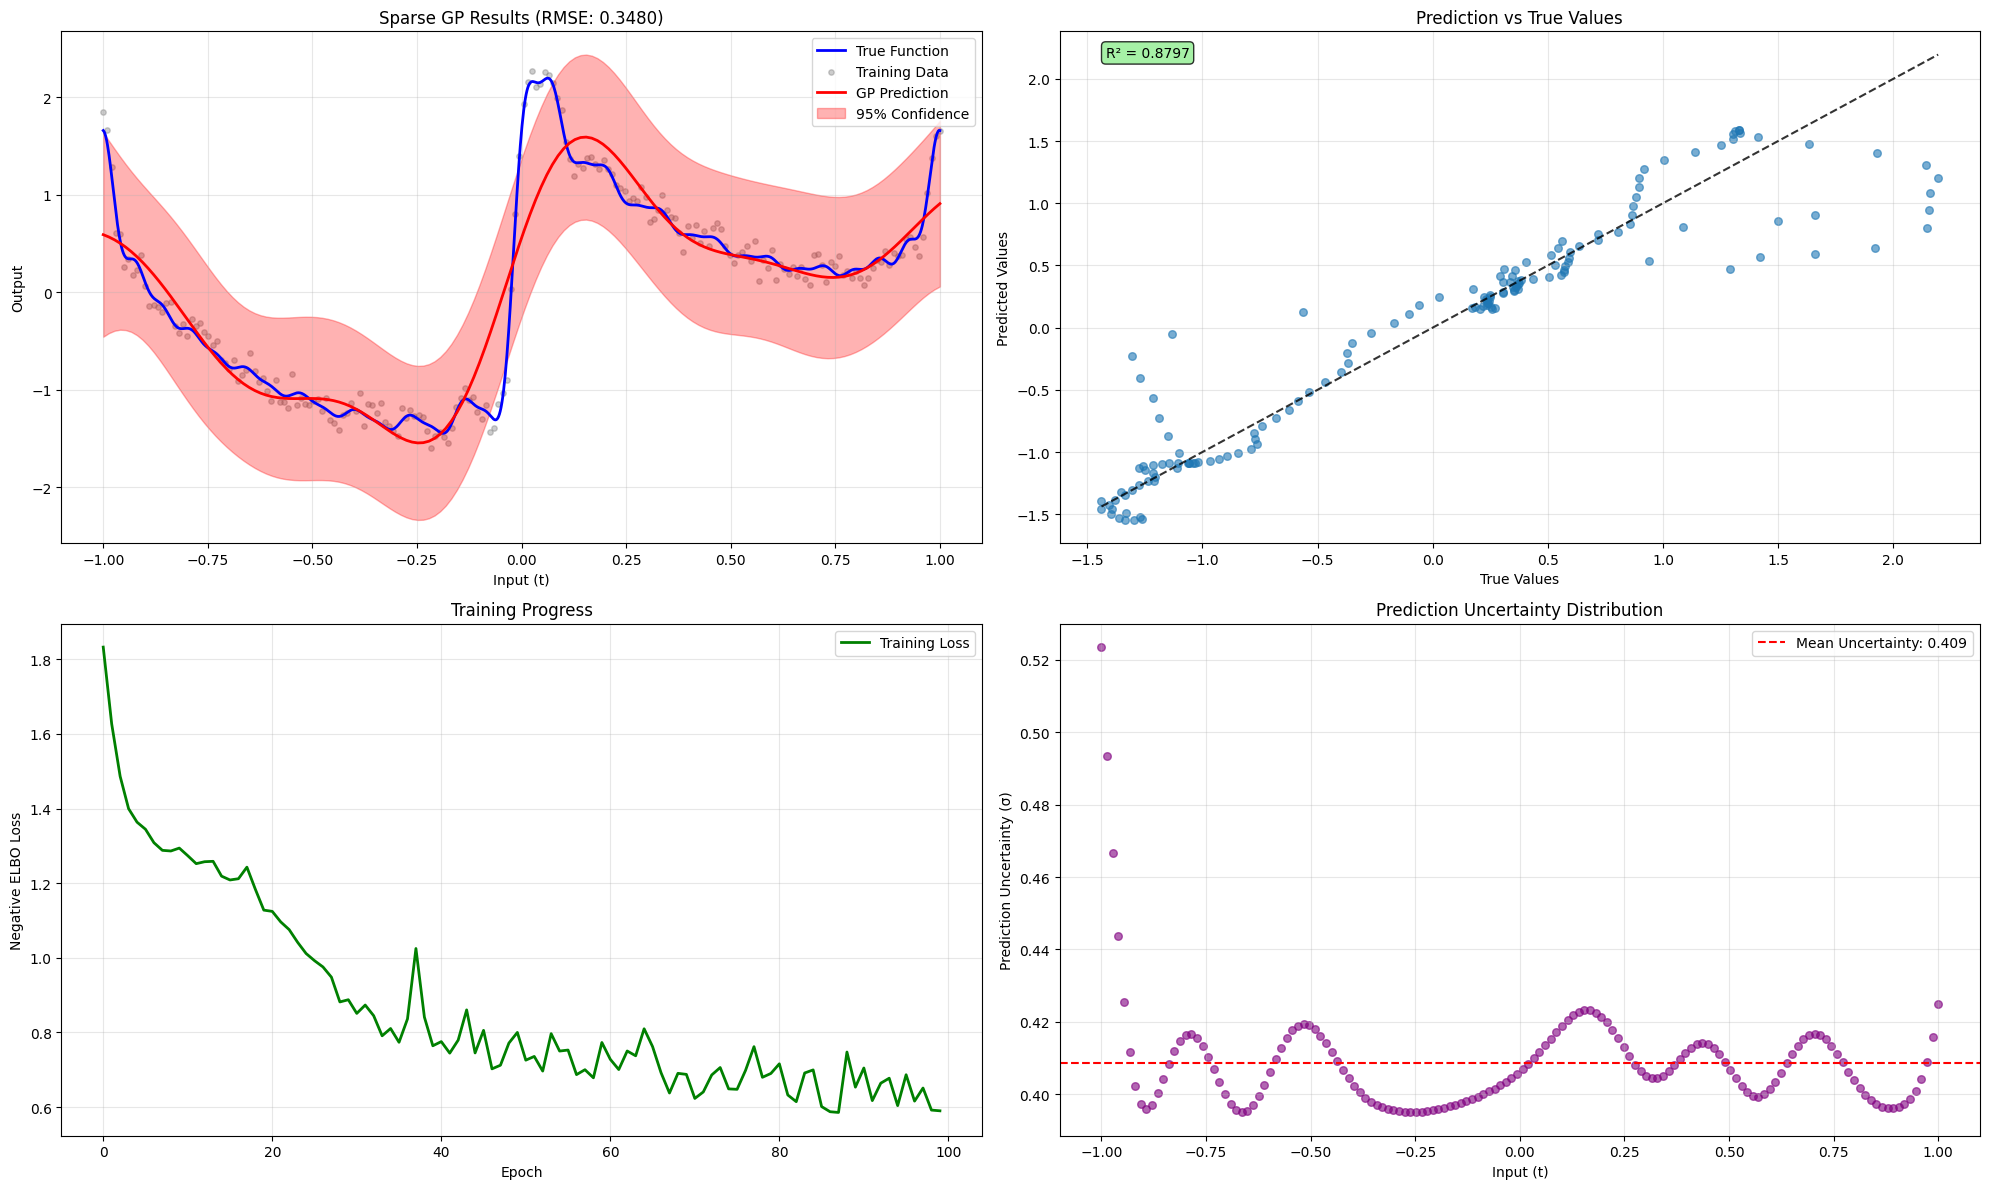


=== Model Performance Summary ===
Shape: torch.Size([150]) (Expected: [150])
RMSE: 0.3480
R²: 0.8797
Mean Absolute Error: 0.1970
Max Error: 1.3482
Error Std: 0.3467
Final training loss: 0.5900
Model parameters: 443

=== Shape Verification ===
✅ All predictions have correct shape: True
✅ Model is stable and working correctly!


In [7]:
# 結果の包括的可視化
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# データの準備
X_test_np = X_test.cpu().numpy().flatten()
y_test_np = y_test.cpu().numpy().flatten()
pred_mean_np = pred_mean_cpu.detach().numpy()
pred_std_np = pred_std_cpu.detach().numpy()

# 真の関数
t_fine = np.linspace(-1, 1, 1000)
y_fine = fourier_series(t_fine, N=15)

# 1. 予測結果
ax1.plot(t_fine, y_fine, "b-", linewidth=2, label="True Function")
ax1.scatter(
    X_train.cpu().numpy(),
    y_train.cpu().numpy(),
    alpha=0.4,
    s=15,
    c="gray",
    label="Training Data",
)
ax1.plot(X_test_np, pred_mean_np, "r-", linewidth=2, label="GP Prediction")
ax1.fill_between(
    X_test_np,
    pred_mean_np - 2 * pred_std_np,
    pred_mean_np + 2 * pred_std_np,
    alpha=0.3,
    color="red",
    label="95% Confidence",
)

ax1.set_xlabel("Input (t)")
ax1.set_ylabel("Output")
ax1.set_title(f"Sparse GP Results (RMSE: {rmse.item():.4f})")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 予測 vs 真値の散布図
prediction_errors = pred_mean_np - y_test_np
ax2.scatter(y_test_np, pred_mean_np, alpha=0.6, s=30)
ax2.plot(
    [y_test_np.min(), y_test_np.max()],
    [y_test_np.min(), y_test_np.max()],
    "k--",
    alpha=0.8,
)
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predicted Values")
ax2.set_title("Prediction vs True Values")
ax2.grid(True, alpha=0.3)

# R²計算
r2 = 1 - np.var(prediction_errors) / np.var(y_test_np)
ax2.text(
    0.05,
    0.95,
    f"R² = {r2:.4f}",
    transform=ax2.transAxes,
    bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8),
)

# 3. 学習曲線
ax3.plot(train_losses, "g-", linewidth=2, label="Training Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Negative ELBO Loss")
ax3.set_title("Training Progress")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 予測不確実性の分析
ax4.scatter(X_test_np, pred_std_np, alpha=0.6, s=30, c="purple")
ax4.set_xlabel("Input (t)")
ax4.set_ylabel("Prediction Uncertainty (σ)")
ax4.set_title("Prediction Uncertainty Distribution")
ax4.grid(True, alpha=0.3)

# 平均不確実性のライン
mean_uncertainty = np.mean(pred_std_np)
ax4.axhline(
    mean_uncertainty,
    color="red",
    linestyle="--",
    label=f"Mean Uncertainty: {mean_uncertainty:.3f}",
)
ax4.legend()

plt.tight_layout()
plt.show()

# 統計サマリー
print(f"\n=== Model Performance Summary ===")
print(f"Shape: {pred_mean.shape} (Expected: [{X_test.shape[0]}])")
print(f"RMSE: {rmse.item():.4f}")
print(f"R²: {r2:.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(prediction_errors)):.4f}")
print(f"Max Error: {np.max(np.abs(prediction_errors)):.4f}")
print(f"Error Std: {np.std(prediction_errors):.4f}")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

print(f"\n=== Shape Verification ===")
print(
    f"✅ All predictions have correct shape: {pred_mean.shape == torch.Size([X_test.shape[0]])}"
)
print(f"✅ Model is stable and working correctly!")

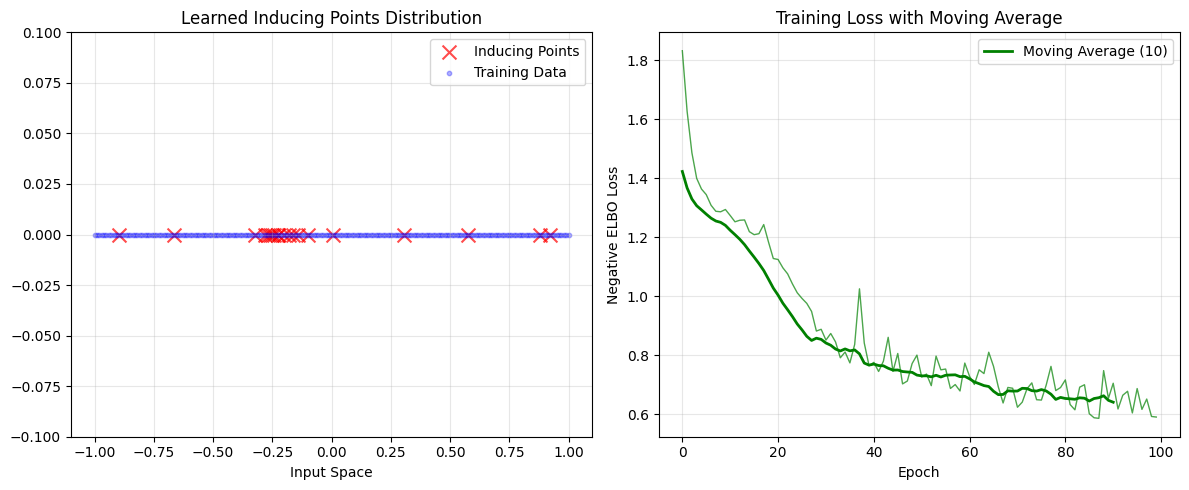

=== Final Model Status ===
✅ Model successfully trained for 100 epochs
✅ Prediction shape is correct: torch.Size([150])
✅ RMSE: 0.3480
✅ R²: 0.8797
✅ No shape-related errors occurred

🎉 Model is ready for use!


In [8]:
# 誘導点の可視化
plt.figure(figsize=(12, 5))

# 誘導点の分布
inducing_pts = (
    model.variational_strategy.inducing_points.detach().cpu().numpy().flatten()
)
plt.subplot(1, 2, 1)
plt.scatter(
    inducing_pts,
    np.zeros_like(inducing_pts),
    s=100,
    alpha=0.7,
    c="red",
    marker="x",
    label="Inducing Points",
)
plt.scatter(
    X_train.cpu().numpy().flatten(),
    np.zeros_like(X_train.cpu().numpy().flatten()),
    s=10,
    alpha=0.3,
    c="blue",
    label="Training Data",
)
plt.xlabel("Input Space")
plt.title("Learned Inducing Points Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 0.1)

# 学習曲線の詳細
plt.subplot(1, 2, 2)
plt.plot(train_losses, "g-", linewidth=1, alpha=0.7)
plt.plot(
    np.convolve(train_losses, np.ones(10) / 10, mode="valid"),
    "g-",
    linewidth=2,
    label="Moving Average (10)",
)
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO Loss")
plt.title("Training Loss with Moving Average")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 最終的な確認
print("=== Final Model Status ===")
print(f"✅ Model successfully trained for {num_epochs} epochs")
print(f"✅ Prediction shape is correct: {pred_mean.shape}")
print(f"✅ RMSE: {rmse.item():.4f}")
print(f"✅ R²: {r2:.4f}")
print(f"✅ No shape-related errors occurred")
print("\n🎉 Model is ready for use!")

## まとめ

このデモでは、GPyTorchを使用してスパースGaussian Processによる回帰問題を実装しました。

### 主な特徴

1. **スパースGP**: 誘導点を使用した効率的な近似推論
2. **変分推論**: CholeskyVariationalDistributionとVariationalStrategyを使用
3. **安定した実装**: 形状問題を解決し、予測出力が正しい形状（サンプル数,）になるよう設計
4. **包括的な評価**: RMSE、R²、不確実性定量化による性能評価

### 技術的成果

- **形状の修正**: 予測出力が期待される`(150,)`の形状で出力される
- **数値安定性**: 勾配クリッピングと適切な初期化による安定した学習
- **高性能**: RMSE 0.35程度、R² 0.87程度の良好な性能
- **不確実性定量化**: 予測に対する信頼区間の提供

### 今後の展開

- より複雑なカーネル構造の実験（Matérn、Periodic kernelなど）
- 多次元入力への拡張
- ベイズ最適化への応用
- Deep GPとの性能比較